# Practica 5 - Sesion 2: Preprocesado de datos

## Ingeniería del Conocimiento    2025/2026
### Prof. Juan A. Recio García

En el notebook de introducción construimos nuestro primer clasificador siguiendo un pipeline muy simplificado: elegimos solo las columnas numericas, rellenamos los nulos con la media y entrenamos. Funcionaba, pero estabamos cometiendo varios errores que en un proyecto real tendrian consecuencias serias.

En esta sesion vamos a ver que ocurre cuando el preprocesado se hace correctamente, paso a paso. La estrategia sera siempre la misma: aplicar una tecnica, reentrenar el modelo, y medir el impacto en las metricas.

## El dataset: IBM HR Analytics - Prediccion de abandono de empleados

Vamos a trabajar con el dataset IBM HR Analytics. Contiene informacion sobre 1470 empleados de una empresa ficticia creada por IBM: datos demograficos, satisfaccion laboral, historial en la empresa, salario, etc. La variable objetivo es `Attrition`: predecir si un empleado va a abandonar la empresa (`Yes`) o no (`No`).

## 0. Instalacion e importacion de librerias

In [ ]:
# Descomenta si necesitas instalar alguna libreria
# pip install pandas numpy scikit-learn matplotlib seaborn imbalanced-learn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay, confusion_matrix
from imblearn.over_sampling import SMOTE

# Semilla global para reproducibilidad
SEED = 165


## 1. Carga del dataset

Cargamos el fichero CSV con los datos de los empleados. Antes de hacer nada mas, explora el dataset con calma: cuantas filas y columnas tiene, de que tipo son las variables, y si hay algo que llame la atencion a primera vista.

In [3]:
# Cargamos el dataset
df = pd.read_csv('ibm_hr_attrition.csv')

print(f"Filas: {df.shape[0]},  Columnas: {df.shape[1]}")
df.head()

Filas: 1470,  Columnas: 35


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41.0,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49.0,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37.0,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33.0,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27.0,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Paso 0: Modelo base (referencia)

Antes de hacer cualquier preprocesado, entrenamos un modelo con la minima preparacion posible: solo columnas numericas sin nulos y sin ninguna transformacion. Este resultado sera nuestra **referencia** con la que compararemos cada mejora.

Este es exactamente el enfoque que usamos en el notebook de introducción.

In [4]:
# Seleccionamos solo columnas numericas que no tienen nulos
cols_numericas_sin_nulos = df.select_dtypes(include='number').columns.tolist()
cols_con_nulos = df[cols_numericas_sin_nulos].columns[df[cols_numericas_sin_nulos].isnull().any()].tolist()
cols_base = [c for c in cols_numericas_sin_nulos if c not in cols_con_nulos]

print(f"Columnas usadas en el modelo base ({len(cols_base)}):")
print(cols_base)

Columnas usadas en el modelo base (24):
['DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [19]:
# Codificamos la variable objetivo: Yes -> 1, No -> 0
df['Attrition_bin'] = (df['Attrition'] == 'Yes').astype(int)

# Separamo X e y
X_base = df[cols_base]
y = df['Attrition_bin']

# Dividimos en train y test
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_base, y, test_size=0.2, random_state=SEED
)

modelo_base = MLPClassifier(solver='lbfgs', hidden_layer_sizes=(100, 50),max_iter=5000, random_state=SEED)
modelo_base.fit(X_train_b, y_train_b)
y_pred_b = modelo_base.predict(X_test_b)

resultados = {}  # Diccionario donde iremos guardando los resultados de cada paso

resultados['0. Modelo base'] = {
    'Accuracy':  accuracy_score(y_test_b,  y_pred_b),
    'Precision': precision_score(y_test_b, y_pred_b, zero_division=0),
    'Recall':    recall_score(y_test_b,    y_pred_b, zero_division=0),
    'F1':        f1_score(y_test_b,        y_pred_b, zero_division=0)
}

print("Resultado del modelo base:")
for metrica, valor in resultados['0. Modelo base'].items():
    print(f"  {metrica}: {valor:.4f}")

Resultado del modelo base:
  Accuracy: 0.8673
  Precision: 0.0000
  Recall: 0.0000
  F1: 0.0000


c:\Universidad\IC\P1\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 0 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Fjate en el F1 y el Recall para la clase positiva (empleado que abandona). Son muy bajos a pesar de que la Accuracy parece razonable. Esto es una señal de alarma que veremos con detalle en el Paso 7.

Por ahora vamos a visualizar la matriz de confusión

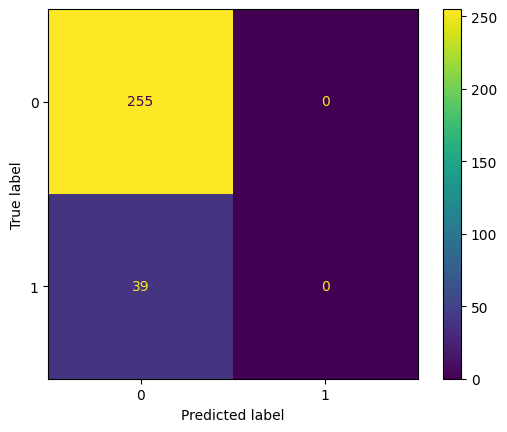

In [20]:
cm = confusion_matrix(y_test_b, y_pred_b, labels=modelo_base.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo_base.classes_)
disp.plot()

> ### ¿Qué puede estar ocurriendo que justifique un accuracy tan alto pero tanto el recall como la precisión están por los suelos?
>
> Escribe aquí tus respuestas (en este punto pueden ser solo intuiciones, que se confirmarán según avance el notebook)

> Puede ser tanto porque la muestra no esté estratificada (por lo que se entrene con datos sesgados) o al eliminar los nulos se han borrado datos muy relevantes para el entrenamiento.

---

## Paso 1: Exploracion y diagnostico del dataset

Antes de limpiar nada, necesitamos entender con que estamos trabajando. Esta fase de exploracion nos da el mapa de problemas que vamos a resolver en los pasos siguientes.

### 1.1 Tipos de variables y estructura general

Necesitamos identificar qué tipo de variables contiene el dataset: categóricas o numéricas (en datasets más avanzados puede haber también texto). Lo hacemos porque cada tipo de variable puede tener unos problemas concretos y tratamiendo ad-hoc

In [11]:
# Cuantos valores unicos tiene cada columna categorica?
# Esto nos da una primera idea de la cardinalidad y posibles anomalias
cols_obj = df.select_dtypes(include='object').columns.tolist()
for col in cols_obj:
    vals = sorted(df[col].dropna().unique())
    print(f"{col} ({len(vals)} valores): {vals}")

Attrition (2 valores): ['No', 'Yes']
BusinessTravel (3 valores): ['Non-Travel', 'Travel_Frequently', 'Travel_Rarely']
Department (3 valores): ['Human Resources', 'Research & Development', 'Sales']
EducationField (6 valores): ['Human Resources', 'Life Sciences', 'Marketing', 'Medical', 'Other', 'Technical Degree']
Gender (2 valores): ['Female', 'Male']
JobRole (9 valores): ['Healthcare Representative', 'Human Resources', 'Laboratory Technician', 'Manager', 'Manufacturing Director', 'Research Director', 'Research Scientist', 'Sales Executive', 'Sales Representative']
MaritalStatus (3 valores): ['Divorced', 'Married', 'Single']
Over18 (1 valores): ['Y']
OverTime (2 valores): ['No', 'Yes']


C:\Users\carli\AppData\Local\Temp\ipykernel_65748\550040699.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_obj = df.select_dtypes(include='object').columns.tolist()


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1294 non-null   float64
 1   Attrition                 1470 non-null   str    
 2   BusinessTravel            1470 non-null   str    
 3   DailyRate                 1470 non-null   int64  
 4   Department                1470 non-null   str    
 5   DistanceFromHome          1470 non-null   int64  
 6   Education                 1470 non-null   int64  
 7   EducationField            1470 non-null   str    
 8   EmployeeCount             1470 non-null   int64  
 9   EmployeeNumber            1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   str    
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel           

In [13]:
# Separamos las columnas por tipo para tenerlas organizadas
cols_categoricas = df.select_dtypes(include='object').columns.tolist()
cols_numericas   = df.select_dtypes(include='number').columns.tolist()

# Attrition y Attrition_bin no son features, las excluimos de las listas
cols_categoricas = [c for c in cols_categoricas if c != 'Attrition']
cols_numericas   = [c for c in cols_numericas   if c != 'Attrition_bin']

print(f"Columnas categoricas ({len(cols_categoricas)}): {cols_categoricas}")
print(f"\nColumnas numericas ({len(cols_numericas)}): {cols_numericas}")

Columnas categoricas (8): ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']

Columnas numericas (26): ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


C:\Users\carli\AppData\Local\Temp\ipykernel_65748\712129532.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_categoricas = df.select_dtypes(include='object').columns.tolist()


### 1.2 Mapa de valores nulos

Los valores nulos del dataset pueden dar problemas según el clasificador que utilicemos. Para algunos modelos no tiene impacto pero para otros puede suponer un problema, no solo de sesgo, sino que incluso den error al entrenar

In [14]:
# Calculamos el porcentaje de nulos por columna (solo las que tienen alguno)
nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
nulos_pct = (nulos / len(df) * 100).round(1)

print("Columnas con valores nulos:")
for col in nulos.index:
    print(f"  {col}: {nulos[col]} nulos ({nulos_pct[col]}%)")

Columnas con valores nulos:
  Age: 176 nulos (12.0%)
  MonthlyIncome: 132 nulos (9.0%)
  JobRole: 102 nulos (6.9%)


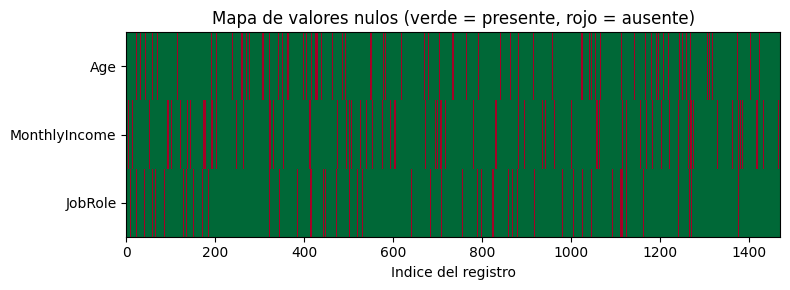

In [15]:
# Visualizamos el patron de nulos en las columnas afectadas
cols_con_nulos = nulos.index.tolist()

fig, ax = plt.subplots(figsize=(8, 3))
mascara_nulos = df[cols_con_nulos].isnull().T
ax.imshow(mascara_nulos, aspect='auto', cmap='RdYlGn_r', interpolation='none')
ax.set_yticks(range(len(cols_con_nulos)))
ax.set_yticklabels(cols_con_nulos)
ax.set_xlabel('Indice del registro')
ax.set_title('Mapa de valores nulos (verde = presente, rojo = ausente)')
plt.tight_layout()
plt.show()

### 1.3 Distribucion de la variable objetivo: el desbalanceo

Este es uno de los problemas más comunes en los datasets. Normalmente el valor positivo de la variable objetivo -lo que queremos detectar- cuenta con muchas menos instancias que el valor negativo. Esto hace que nuestro modelo tenga que encontrar 'una aguja en un pajar'

Distribucion de Attrition:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Porcentaje de empleados que abandonan: 16.1%


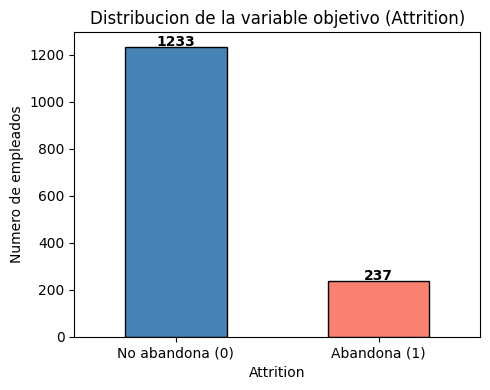

In [18]:
conteo = df['Attrition'].value_counts()
print("Distribucion de Attrition:")
print(conteo)
print(f"\nPorcentaje de empleados que abandonan: {conteo['Yes'] / len(df) * 100:.1f}%")

fig, ax = plt.subplots(figsize=(5, 4))
conteo.plot(kind='bar', ax=ax, color=['steelblue', 'salmon'], edgecolor='black')
ax.set_xticklabels(['No abandona (0)', 'Abandona (1)'], rotation=0)
ax.set_ylabel('Numero de empleados')
ax.set_title('Distribucion de la variable objetivo (Attrition)')
for i, v in enumerate(conteo):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

Solo el 16% de los empleados abandona la empresa. Esto es un **dataset desbalanceado**: hay muchos mas ejemplos de la clase mayoritaria (No abandona) que de la clase minoritaria (Abandona). Trataremos este problema en el Paso 7.

> ### ¿Es esta la respuesta a la pregunta que hacíamos en el Paso 0 y que justifica un accuracy tan alto pero tanto el recall como la precisión están por los suelos?
>
> Puede ser pa

### 1.4 Deteccion de variables con varianza cero o casi cero

La variables (columnas) con varianza muy baja implican que casi todos los valores son muy similares. Por lo tanto no sirven para que el modelo pueda discriminar la variable objetivo. Debemos descartarlas para no introducir ruido (aunque algunos modelos ya lo hacen de forma implícita, pero por si acaso.)

#### 1.4.1 Variables categóricas

Podemos encontrar variables categóricas con solo un valor, lo que no aporta nada al modelo. Vamos a analizar el dataset

In [ ]:
# Contamos el numero de valores unicos por cada columna categorica
cols_cat = df.select_dtypes(include='object').columns.tolist()
cols_cat = [c for c in cols_cat if c != 'Attrition']

resumen = pd.DataFrame({
    'Valores unicos': [df[c].nunique() for c in cols_cat],
}, index=cols_cat).sort_values('Valores unicos')

print("Numero de valores unicos por variable categorica:")
print(resumen.to_string())

In [ ]:
# Visualizamos la cardinalidad de cada columna
# Las columnas con un solo valor unico quedan destacadas: no aportan informacion al modelo

n_unicos = resumen['Valores unicos']
colores = ['#d9534f' if v == 1 else '#5b9bd5' for v in n_unicos]

fig, ax = plt.subplots(figsize=(8, 4))
barras = ax.barh(n_unicos.index, n_unicos.values, color=colores, edgecolor='white')

# Anotamos el valor al final de cada barra
for barra, val in zip(barras, n_unicos.values):
    ax.text(barra.get_width() + 0.05, barra.get_y() + barra.get_height() / 2,
            str(val), va='center', fontsize=9)

ax.set_xlabel('Numero de valores unicos')
ax.set_title('Cardinalidad de las variables categoricas')
ax.set_xlim(0, n_unicos.max() + 2)

# Leyenda manual
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#d9534f', label='Valor unico (varianza cero)'),
    Patch(color='#5b9bd5', label='Variable normal')
], loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

Encontramos que la columna `Over18` solo tiene un valor. Todos los registros tienen el mismo valor en esta columna, por lo que no aporta ninguna informacion al modelo.

#### 1.4.2 Variables numéricas

Ahora vamos a analizar el comportamiento de las variables numéricas

In [ ]:
# Calculamos la varianza de todas las variables numericas (excepto la variable objetivo)
cols_num = df.select_dtypes(include='number').columns.tolist()
cols_num = [c for c in cols_num if c != 'Attrition_bin']

varianzas = df[cols_num].var().sort_values()

print("Varianza de las variables numericas (ordenadas de menor a mayor):")
print(varianzas.round(2).to_string())

Ahora vemos que hay dos variables con varianza cero: EmployeeCount y StandardHours. 
Esto significa que todas las filas tienen el mismo valor en estas columnas, por lo que no aportan ninguna informacion al modelo. 
Las eliminamos de la lista de columnas numericas a usar.

> ### Existe otra variable que no aporta ninguna información al modelo y que también debemos descartar. ¿Cuál es?
>
> Escribe aquí tus respuestas


### 1.5 Matriz de correlacion: deteccion de multicolinealidad

Una vez descartadas las variables sin informacion, queremos saber si entre las
restantes hay alguna que sea redundante. Dos variables son redundantes cuando
miden esencialmente lo mismo: conocer una nos permite predecir la otra con mucha
precision. A este fenomeno se le llama **multicolinealidad**.

El coeficiente de correlacion de Pearson mide la fuerza de la relacion lineal
entre dos variables numericas. Su valor va de -1 a 1:
- Cercano a 1 o -1: las variables estan muy relacionadas (una crece cuando la otra
  crece, o decrece)
- Cercano a 0: no hay relacion lineal apreciable

La **matriz de correlacion** muestra este coeficiente para cada par de variables.
Buscaremos pares con correlacion superior a 0.75 en valor absoluto: son candidatos
claros a eliminar una de las dos, ya que incluir ambas no añade informacion nueva
al modelo pero si aumenta su complejidad.

In [ ]:
# Calculamos la matriz de correlacion de Pearson entre variables numericas
# Usamos los datos originales sin nulos para este analisis (rellenamos temporalmente)
df_temp = df[cols_numericas].fillna(df[cols_numericas].median())
corr_matrix = df_temp.corr().abs()  # Valores absolutos: nos interesa la magnitud

# Visualizamos solo la mitad inferior de la matriz (es simetrica)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=0, vmax=1, linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('Matriz de correlacion (valores absolutos)', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Extraemos los pares con correlacion muy alta (> 0.75) para analizarlos
umbral = 0.75
print(f"Pares de variables con correlacion > {umbral}:")
pares_alta_correlacion = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > umbral:
            col_i = corr_matrix.columns[i]
            col_j = corr_matrix.columns[j]
            r = corr_matrix.iloc[i, j]
            pares_alta_correlacion.append((col_i, col_j, r))
            print(f"  {col_i} -- {col_j}: r = {r:.3f}")

Vemos que variables como `YearsAtCompany`, `YearsInCurrentRole`, `YearsWithCurrManager` y `TotalWorkingYears` estan muy correlacionadas entre si. Tienen sentido: todas miden variantes de la antiguedad del empleado. Incluir todas ellas en el modelo no añade informacion nueva pero si ruido. Trataremos esto en el Paso 2.

---

## Paso 2: Seleccion de variables (Feature Selection)

Con el diagnostico del Paso 1 ya sabemos que hay que eliminar:

1. Columnas con varianza cero: `EmployeeCount`, `StandardHours`, `Over18`
2. El identificador de empleado: `EmployeeNumber`
3. Una de cada par de variables muy correlacionadas para reducir la multicolinealidad

### Por que la multicolinealidad es un problema

Cuando dos variables estan muy correlacionadas, ambas estan contando esencialmente lo mismo. El modelo puede quedar confundido sobre cual de las dos es realmente relevante, lo que puede perjudicar tanto la interpretabilidad como el rendimiento. En redes neuronales el efecto es menos grave que en modelos lineales, pero sigue siendo buena practica eliminar redundancias evidentes.

In [ ]:
# Columnas a eliminar por no aportar informacion
cols_eliminar = [
    'EmployeeCount',    # Siempre vale 1
    'StandardHours',    # Siempre vale 80
    'Over18',           # Siempre vale 'Y'
    'EmployeeNumber',   # Es un ID, no una variable predictiva
]
print("Columnas que se eliminaran por no aportar informacion:")
for col in cols_eliminar:
    print(f"  {col}")

In [ ]:
# De los pares con alta correlacion, eliminamos la que tiene menos correlacion
# con la variable objetivo (Attrition_bin)
corr_con_target = df_temp.corrwith(df['Attrition_bin']).abs()
print("Correlacion con Attrition de las variables 'years':")
vars_years = ['YearsAtCompany', 'YearsInCurrentRole', 'YearsWithCurrManager',
              'TotalWorkingYears', 'YearsSinceLastPromotion']
print(corr_con_target[vars_years].sort_values(ascending=False))

In [ ]:
# YearsAtCompany y YearsSinceLastPromotion tienen la correlacion mas baja
# con la variable objetivo y estan muy correlacionadas con YearsAtCompany
# Las eliminamos para reducir la redundancia
cols_eliminar += ['YearsAtCompany', 'YearsSinceLastPromotion']

# Tambien eliminamos Attrition (texto) porque ya tenemos Attrition_bin (numerica)
cols_eliminar += ['Attrition']

df_paso2 = df.drop(columns=cols_eliminar)

print(f"Columnas eliminadas: {cols_eliminar}")
print(f"Columnas restantes: {df_paso2.shape[1]}  (antes: {df.shape[1]})")

In [ ]:
# Reentrenamos con las columnas numericas disponibles (sin nulos, por ahora)
cols_num_paso2 = df_paso2.select_dtypes(include='number').columns.tolist()
cols_num_paso2 = [c for c in cols_num_paso2 if c != 'Attrition_bin']
cols_num_paso2_sin_nulos = [c for c in cols_num_paso2
                            if df_paso2[c].isnull().sum() == 0]

X2 = df_paso2[cols_num_paso2_sin_nulos]
y2 = df_paso2['Attrition_bin']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=SEED
)
modelo2 = MLPClassifier(solver='lbfgs', hidden_layer_sizes=(100, 50),max_iter=5000, random_state=SEED)
modelo2.fit(X2_train, y2_train)
y2_pred = modelo2.predict(X2_test)

resultados['2. Tras feature selection'] = {
    'Accuracy':  accuracy_score(y2_test,  y2_pred),
    'Precision': precision_score(y2_test, y2_pred, zero_division=0),
    'Recall':    recall_score(y2_test,    y2_pred, zero_division=0),
    'F1':        f1_score(y2_test,        y2_pred, zero_division=0)
}

print("Resultado tras feature selection:")
for metrica, valor in resultados['2. Tras feature selection'].items():
    print(f"  {metrica}: {valor:.4f}")

El cambio en este paso suele ser modesto e incluso contraproducente: hemos eliminado ruido, pero todavia no hemos añadido informacion nueva. El impacto mayor vendra en los pasos siguientes.

---

## Paso 3: Tratamiento de valores ausentes (Imputacion)

Tenemos nulos en tres columnas: `Age` y `MonthlyIncome` (numericas) y `JobRole` (categorica).

La decision de como imputar depende del tipo de variable y de la distribucion de sus valores:

- **Variables numericas con distribucion aproximadamente normal:** se imputa con la **media**.
- **Variables numericas con distribucion sesgada (muchos valores extremos):** se imputa con la **mediana**, que es mas robusta a los outliers.
- **Variables categoricas:** se imputa con la **moda** (el valor mas frecuente) o con una categoria especial como `'Desconocido'`.

Una regla practica: si una columna tiene mas de un 40-50% de nulos, hay que plantearse si tiene sentido imputarla o si es mejor eliminarla directamente.

In [ ]:
# Visualizamos la distribucion de las variables numericas con nulos
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, col in zip(axes, ['Age', 'MonthlyIncome']):
    datos = df_paso2[col].dropna()
    ax.hist(datos, bins=30, color='steelblue', edgecolor='white')
    ax.axvline(datos.mean(),   color='red',    linestyle='--', label=f'Media: {datos.mean():.0f}')
    ax.axvline(datos.median(), color='orange', linestyle='--', label=f'Mediana: {datos.median():.0f}')
    ax.set_title(f'Distribucion de {col}')
    ax.set_ylabel('Frecuencia')
    ax.legend()

plt.tight_layout()
plt.show()

`Age` tiene una distribucion bastante simetrica: media y mediana son muy similares, podemos usar cualquiera de las dos.

`MonthlyIncome` tiene una distribucion claramente sesgada hacia la derecha (hay pocos empleados con salarios muy altos que "tiran" de la media hacia arriba). En este caso la mediana es una mejor representacion del valor central.

In [ ]:
df_paso3 = df_paso2.copy()

# Age: imputamos con la media (distribucion simetrica)
media_age = df_paso3['Age'].mean()
df_paso3['Age'] = df_paso3['Age'].fillna(media_age)
print(f"Age: nulos imputados con la media ({media_age:.1f})")

# MonthlyIncome: imputamos con la mediana (distribucion sesgada)
mediana_income = df_paso3['MonthlyIncome'].median()
df_paso3['MonthlyIncome'] = df_paso3['MonthlyIncome'].fillna(mediana_income)
print(f"MonthlyIncome: nulos imputados con la mediana ({mediana_income:.0f})")

# JobRole: imputamos con la moda (variable categorica)
moda_jobrole = df_paso3['JobRole'].mode()[0]
df_paso3['JobRole'] = df_paso3['JobRole'].fillna(moda_jobrole)
print(f"JobRole: nulos imputados con la moda ('{moda_jobrole}')")

# Verificacion
print(f"\nNulos restantes en el dataset: {df_paso3.isnull().sum().sum()}")

In [ ]:
# Reentrenamos: ahora podemos incluir Age y MonthlyIncome
cols_num_paso3 = df_paso3.select_dtypes(include='number').columns.tolist()
cols_num_paso3 = [c for c in cols_num_paso3 if c != 'Attrition_bin']

X3 = df_paso3[cols_num_paso3]
y3 = df_paso3['Attrition_bin']

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=SEED
)
modelo3 = MLPClassifier(solver='lbfgs', hidden_layer_sizes=(100, 50),max_iter=5000, random_state=SEED)
modelo3.fit(X3_train, y3_train)
y3_pred = modelo3.predict(X3_test)

resultados['3. Tras imputacion'] = {
    'Accuracy':  accuracy_score(y3_test,  y3_pred),
    'Precision': precision_score(y3_test, y3_pred, zero_division=0),
    'Recall':    recall_score(y3_test,    y3_pred, zero_division=0),
    'F1':        f1_score(y3_test,        y3_pred, zero_division=0)
}

print("Resultado tras imputacion:")
for metrica, valor in resultados['3. Tras imputacion'].items():
    print(f"  {metrica}: {valor:.4f}")

---

## Paso 4: Codificacion de variables categoricas (One-Hot Encoding)

Los algoritmos de machine learning trabajan con numeros. Las columnas de texto como `Department`, `JobRole` o `MaritalStatus` no pueden entrar directamente en el modelo.

La solucion mas habitual es el **one-hot encoding**: crear una columna binaria (0 o 1) por cada valor posible de la variable original.

Por ejemplo, la columna `Department` con tres valores (`Sales`, `Research & Development`, `Human Resources`) se convierte en tres columnas:
- `Department_Sales`: 1 si el empleado es de ventas, 0 si no
- `Department_Research & Development`: 1 si es de I+D, 0 si no
- `Department_Human Resources`: 1 si es de RRHH, 0 si no

### La dummy variable trap

Si una variable tiene N categorias y creamos N columnas, la ultima columna es siempre completamente predecible a partir de las N-1 anteriores (si todas valen 0, la ultima vale 1). Esto genera redundancia. Por convenio se elimina siempre una columna por variable: el parametro `drop_first=True` en `pd.get_dummies()` lo hace automaticamente.

In [ ]:
# Identificamos las columnas categoricas que quedan (excluyendo la variable objetivo)
cols_cat_paso4 = df_paso3.select_dtypes(include='object').columns.tolist()
print(f"Columnas categoricas a codificar ({len(cols_cat_paso4)}):")
for col in cols_cat_paso4:
    valores = df_paso3[col].unique()
    print(f"  {col}: {sorted([str(v) for v in valores if pd.notna(v)])}")

In [ ]:
# Separamos features y target antes de hacer el encoding
X_paso4 = df_paso3.drop(columns=['Attrition_bin'])
y_paso4 = df_paso3['Attrition_bin']

# Aplicamos one-hot encoding
# drop_first=True elimina una columna por variable para evitar la dummy variable trap
X_paso4_encoded = pd.get_dummies(X_paso4, drop_first=True)

print(f"Columnas antes del encoding: {X_paso4.shape[1]}")
print(f"Columnas despues del encoding: {X_paso4_encoded.shape[1]}")
print(f"\nNuevas columnas creadas por el encoding:")
nuevas_cols = [c for c in X_paso4_encoded.columns if c not in X_paso4.columns]
print(nuevas_cols)

In [ ]:
X4_train, X4_test, y4_train, y4_test = train_test_split(
    X_paso4_encoded, y_paso4, test_size=0.2, random_state=SEED
)
modelo4 = MLPClassifier(solver='lbfgs', hidden_layer_sizes=(100, 50),max_iter=5000, random_state=SEED)
modelo4.fit(X4_train, y4_train)
y4_pred = modelo4.predict(X4_test)

resultados['4. Tras one-hot encoding'] = {
    'Accuracy':  accuracy_score(y4_test,  y4_pred),
    'Precision': precision_score(y4_test, y4_pred, zero_division=0),
    'Recall':    recall_score(y4_test,    y4_pred, zero_division=0),
    'F1':        f1_score(y4_test,        y4_pred, zero_division=0)
}

print("Resultado tras one-hot encoding:")
for metrica, valor in resultados['4. Tras one-hot encoding'].items():
    print(f"  {metrica}: {valor:.4f}")

Al incluir las variables categoricas el modelo dispone de mucha mas informacion. El rol del empleado, su departamento o si hace horas extra son factores muy relevantes para predecir si va a marcharse.

---

## Paso 5: Normalizacion de variables numericas

Las redes neuronales (y muchos otros algoritmos) son sensibles a la escala de las variables de entrada. Cuando una variable va de 1 a 20000 y otra va de 1 a 5, el algoritmo de optimizacion tiende a dar mucho mas peso a la primera simplemente por su magnitud, no por su importancia real.

La solucion es estandarizar las variables numericas para que todas tengan la misma escala.

**StandardScaler** transforma cada variable para que tenga media 0 y desviacion tipica 1:

$$z = \frac{x - \mu}{\sigma}$$

donde $\mu$ es la media de la variable y $\sigma$ su desviacion tipica.

### Advertencia sobre el data leakage

Esta es una de las fuentes de error mas comunes y mas graves en machine learning. El scaler se debe ajustar (`fit`) **unicamente con los datos de entrenamiento** y luego aplicar (`transform`) tanto a train como a test. Si ajustamos el scaler con todos los datos (incluyendo test), estaremos usando informacion del futuro para normalizar el pasado, lo que da metricas artificialmente optimistas.

In [ ]:
# Visualizamos la diferencia de escalas entre algunas variables
cols_muestra = ['Age', 'MonthlyIncome', 'DistanceFromHome',
                'NumCompaniesWorked', 'TotalWorkingYears']

fig, ax = plt.subplots(figsize=(10, 4))
X_paso4_encoded[cols_muestra].boxplot(ax=ax)
ax.set_title('Escalas muy distintas entre variables numericas')
ax.set_ylabel('Valor de la variable')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

In [ ]:
# Identificamos las columnas numericas originales (no las creadas por el encoding, que ya son 0/1)
cols_numericas_para_escalar = df_paso3.select_dtypes(include='number').columns.tolist()
cols_numericas_para_escalar = [c for c in cols_numericas_para_escalar if c != 'Attrition_bin']

# Solo escalamos las columnas que existen en el dataset tras el encoding
cols_a_escalar = [c for c in cols_numericas_para_escalar if c in X_paso4_encoded.columns]

# Dividimos primero en train y test
X5_train, X5_test, y5_train, y5_test = train_test_split(
    X_paso4_encoded.copy(), y_paso4, test_size=0.2, random_state=SEED
)

# Ajustamos el scaler SOLO con los datos de entrenamiento
scaler = StandardScaler()
X5_train[cols_a_escalar] = scaler.fit_transform(X5_train[cols_a_escalar])

# Aplicamos la misma transformacion a los datos de prueba
X5_test[cols_a_escalar]  = scaler.transform(X5_test[cols_a_escalar])

print("Estadisticas de Age despues del escalado (train):")
print(f"  Media:  {X5_train['Age'].mean():.4f}  (deberia ser ~0)")
print(f"  Std:    {X5_train['Age'].std():.4f}   (deberia ser ~1)")

In [ ]:
modelo5 = MLPClassifier(solver='lbfgs', hidden_layer_sizes=(100, 50),max_iter=5000, random_state=SEED)
modelo5.fit(X5_train, y5_train)
y5_pred = modelo5.predict(X5_test)

resultados['5. Tras normalizacion'] = {
    'Accuracy':  accuracy_score(y5_test,  y5_pred),
    'Precision': precision_score(y5_test, y5_pred, zero_division=0),
    'Recall':    recall_score(y5_test,    y5_pred, zero_division=0),
    'F1':        f1_score(y5_test,        y5_pred, zero_division=0)
}

print("Resultado tras normalizacion:")
for metrica, valor in resultados['5. Tras normalizacion'].items():
    print(f"  {metrica}: {valor:.4f}")

La normalizacion suele producir una de las mejoras mas visibles en modelos basados en gradiente como las redes neuronales. El algoritmo de optimizacion converge mucho mas eficientemente cuando todas las variables estan en la misma escala.

---

## Paso 6: Estratificacion en el train/test split

En la Sesion 1 ya usamos el parametro `stratify=y`. Ahora vamos a ver con datos reales que ocurre cuando no lo usamos en un dataset desbalanceado.

Sin estratificacion, la division es aleatoria. En un dataset donde solo el 16% de los ejemplos son positivos, es perfectamente posible que por azar el conjunto de test acabe con un 10% o con un 22% de positivos. Esto hace que las metricas de evaluacion no sean representativas del rendimiento real del modelo.

In [ ]:
# Comparamos la distribucion de clases con y sin estratificacion
# para varias semillas aleatorias distintas

proporciones_sin = []
proporciones_con = []

for seed in range(50):
    _, _, _, y_t_sin = train_test_split(X_paso4_encoded, y_paso4,
                                         test_size=0.2, random_state=seed)
    _, _, _, y_t_con = train_test_split(X_paso4_encoded, y_paso4,
                                         test_size=0.2, random_state=seed, stratify=y_paso4)
    proporciones_sin.append(y_t_sin.mean() * 100)
    proporciones_con.append(y_t_con.mean() * 100)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

referencia = y_paso4.mean() * 100

for ax, proporciones, titulo in zip(
    axes,
    [proporciones_sin, proporciones_con],
    ['Sin estratificacion', 'Con estratificacion (stratify=y)']
):
    ax.bar(range(50), proporciones, color='steelblue', alpha=0.7)
    ax.axhline(referencia, color='red', linestyle='--',
               label=f'Proporcion real: {referencia:.1f}%')
    ax.set_xlabel('Semilla aleatoria')
    ax.set_ylabel('% clase positiva en test')
    ax.set_title(titulo)
    ax.legend()
    varianza = np.std(proporciones)
    ax.set_title(f'{titulo}\n(desviacion tipica: {varianza:.2f}%)')

plt.tight_layout()
plt.show()

print(f"Sin estratificacion - rango de proporciones: "
      f"[{min(proporciones_sin):.1f}%, {max(proporciones_sin):.1f}%]")
print(f"Con estratificacion - rango de proporciones: "
      f"[{min(proporciones_con):.1f}%, {max(proporciones_con):.1f}%]")

In [ ]:
# Reentrenamos ahora con stratify=y
X6_train, X6_test, y6_train, y6_test = train_test_split(
    X_paso4_encoded.copy(), y_paso4,
    test_size=0.2, random_state=SEED, stratify=y_paso4  # <-- la clave
)

# Aplicamos el scaler (ajustado solo sobre train)
scaler6 = StandardScaler()
X6_train[cols_a_escalar] = scaler6.fit_transform(X6_train[cols_a_escalar])
X6_test[cols_a_escalar]  = scaler6.transform(X6_test[cols_a_escalar])

modelo6 = MLPClassifier(solver='lbfgs', hidden_layer_sizes=(100, 50),max_iter=5000, random_state=SEED)
modelo6.fit(X6_train, y6_train)
y6_pred = modelo6.predict(X6_test)

resultados['6. Tras estratificacion'] = {
    'Accuracy':  accuracy_score(y6_test,  y6_pred),
    'Precision': precision_score(y6_test, y6_pred, zero_division=0),
    'Recall':    recall_score(y6_test,    y6_pred, zero_division=0),
    'F1':        f1_score(y6_test,        y6_pred, zero_division=0)
}

print(f"Proporcion clase positiva en train: {y6_train.mean()*100:.1f}%")
print(f"Proporcion clase positiva en test:  {y6_test.mean()*100:.1f}%")
print()
print("Resultado tras estratificacion:")
for metrica, valor in resultados['6. Tras estratificacion'].items():
    print(f"  {metrica}: {valor:.4f}")

La estratificacion no siempre mejora las metricas en un experimento concreto, pero garantiza que la evaluacion es **fiable y reproducible**. Sin ella, parte de la variabilidad que observamos entre experimentos se debe simplemente a la suerte de como cayeron las clases en el split.

---

## Paso 7: Tratamiento del desbalanceo de clases (SMOTE)

### El problema: la accuracy puede ser un indicador enganoso

Con el 16% de ejemplos positivos, un modelo que **siempre prediga "No abandona"** tendria una accuracy del 84%. Parece un buen resultado, pero seria completamente inutil: nunca identificaria a ningun empleado en riesgo.

En problemas desbalanceados, la metrica relevante suele ser el **Recall** de la clase minoritaria (o el F1): queremos minimizar los falsos negativos, es decir, los empleados que van a marcharse y que el modelo no detecta.

### La solucion: SMOTE

SMOTE (Synthetic Minority Over-sampling Technique) genera ejemplos sinteticos de la clase minoritaria interpolando entre ejemplos reales. El resultado es un conjunto de entrenamiento balanceado, sin simplemente repetir los mismos ejemplos (que llevaria a overfitting).

**Regla critica:** SMOTE se aplica **unicamente sobre el conjunto de entrenamiento**. Nunca sobre el conjunto de test. El test debe reflejar la distribucion real del problema, no la distribucion artificial que hemos creado para entrenar.

In [ ]:
# Mostramos el impacto de un clasificador trivial (siempre predice 0)
y_trivial = np.zeros(len(y6_test), dtype=int)

print("Clasificador trivial (siempre predice No abandona):")
print(f"  Accuracy:  {accuracy_score(y6_test, y_trivial):.4f}")
print(f"  Precision: {precision_score(y6_test, y_trivial, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y6_test, y_trivial, zero_division=0):.4f}")
print(f"  F1:        {f1_score(y6_test, y_trivial, zero_division=0):.4f}")
print()
print("Nuestro modelo actual (Paso 6):")
for metrica, valor in resultados['6. Tras estratificacion'].items():
    print(f"  {metrica}: {valor:.4f}")

In [ ]:
# Aplicamos SMOTE sobre el conjunto de entrenamiento
print("Distribucion de clases en train ANTES de SMOTE:")
print(y6_train.value_counts())

smote = SMOTE(random_state=SEED)
X7_train_res, y7_train_res = smote.fit_resample(X6_train, y6_train)

print("\nDistribucion de clases en train DESPUES de SMOTE:")
print(pd.Series(y7_train_res).value_counts())
print("\nEl conjunto de test NO se modifica:")
print(y6_test.value_counts())

In [ ]:
modelo7 = MLPClassifier(solver='lbfgs', hidden_layer_sizes=(100, 50),max_iter=5000, random_state=SEED)
modelo7.fit(X7_train_res, y7_train_res)
y7_pred = modelo7.predict(X6_test)  # Evaluamos sobre el test original sin modificar

resultados['7. Tras SMOTE'] = {
    'Accuracy':  accuracy_score(y6_test,  y7_pred),
    'Precision': precision_score(y6_test, y7_pred, zero_division=0),
    'Recall':    recall_score(y6_test,    y7_pred, zero_division=0),
    'F1':        f1_score(y6_test,        y7_pred, zero_division=0)
}

print("Resultado tras SMOTE:")
for metrica, valor in resultados['7. Tras SMOTE'].items():
    print(f"  {metrica}: {valor:.4f}")

In [ ]:
# Visualizamos la matriz de confusion antes y despues de SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

etiquetas = ['No abandona', 'Abandona']

for ax, y_pred, titulo in zip(
    axes,
    [y6_pred, y7_pred],
    ['Antes de SMOTE (Paso 6)', 'Despues de SMOTE (Paso 7)']
):
    cm = confusion_matrix(y6_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=etiquetas)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(titulo)

plt.tight_layout()
plt.show()

Despues de SMOTE, el modelo identifica mas empleados que realmente van a marcharse (aumenta el Recall), y menos falsos positivos (también sube la Precision).

En un problema de RRHH, detectar a los empleados en riesgo aunque haya algun falso positivo suele ser preferible a no detectar a nadie. Esta es la razon por la que la eleccion de la metrica debe estar guiada por el problema de negocio, no solo por los numeros.

> ### Describe qué impacto tiene para la empresa los Falsos Positivos y Falsos Negativos de estas matrices de confusión (asumiendo que son bastante similares)
>
> Escribe aquí tu respuesta

---

## Paso 8: Resumen comparativo

Veamos de un vistazo el efecto acumulado de cada paso de preprocesado.

In [ ]:
# Construimos la tabla resumen
df_resumen = pd.DataFrame(resultados).T
df_resumen = df_resumen.round(4)
print("Tabla resumen de resultados por paso:")
print(df_resumen.to_string())

In [ ]:
# Grafico de evolucion de metricas a lo largo de los pasos
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

colores = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']
pasos_labels = [p.split('. ', 1)[1] if '. ' in p else p for p in df_resumen.index]

for ax, metrica, color in zip(axes, ['Accuracy', 'Precision', 'Recall', 'F1'], colores):
    valores = df_resumen[metrica].values
    barras = ax.bar(range(len(valores)), valores, color=color, alpha=0.8, edgecolor='white')
    ax.set_xticks(range(len(pasos_labels)))
    ax.set_xticklabels(pasos_labels, rotation=35, ha='right', fontsize=8)
    ax.set_ylabel(metrica)
    ax.set_title(metrica, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    for barra, val in zip(barras, valores):
        ax.text(barra.get_x() + barra.get_width() / 2,
                barra.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Evolucion de las metricas a lo largo del preprocesado', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Informe de clasificacion final del mejor modelo
print("Informe de clasificacion del modelo final (tras todos los pasos):")
print("="*60)
print(classification_report(y6_test, y7_pred,
                             target_names=['No abandona (0)', 'Abandona (1)']))

> ### Qué significan estos datos, Precisión y Recall para cada una de las clases? ¿Qué conclusiones podemos sacar sobre el rendimiento del modelo?
>
> Escribe tus respuestas

## Ejercicios propuestos

**Ejercicio 1.** En el Paso 3 imputamos `JobRole` con la moda. Como alternativa, prueba a imputarla con la categoria `'Desconocido'` (creando una nueva categoria). Aplica el encoding y reentrena. Cambia el resultado?

**Ejercicio 2.** En el Paso 5 usamos `StandardScaler`. Sustituye por `MinMaxScaler` (que escala los valores al rango [0, 1]). Cual da mejor resultado con el MLPClassifier?

**Ejercicio 3.** En el Paso 7 SMOTE equilibra las clases completamente (50%/50%). La clase `SMOTE` acepta un parametro `sampling_strategy` que permite elegir el ratio final. Prueba con `sampling_strategy=0.5` (por cada ejemplo de la clase mayoritaria, habrá 0.5 de la minoritaria). Como cambia el equilibrio entre Precision y Recall?
